In [1]:
"""
End-to-End Machine Learning Pipeline for Construction Accident Severity Prediction


This script uses the provided dataset to predict the `Type of Accident` (our target variable) using multiple models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- KNN


The pipeline includes:
1. Data loading and preprocessing
2. Handling missing values
3. Feature encoding and scaling
4. Model training and evaluation
5. Comparison of model performance
6. Saving the best model
"""


# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

<span style="font-family:Georgia; font-size:15px; color:gold;">***Machine Learning Pipeline for construction accident Severity prediction***</span>

In [2]:
# Step 1: Load dataset
file_path = "spss revised data 21.10.25.xlsx"
df = pd.read_excel(file_path, engine='openpyxl')

In [3]:
df['Partofbodyaffected'].value_counts()

Partofbodyaffected
Legs       170
Hands      168
Fingers    123
Head        73
Back        46
Eyes        44
Death       34
Ribs        25
Knees       23
Hip          8
Name: count, dtype: int64

In [4]:
# Step 2: Initial Data Exploration

print("Initial Data Shape:", df.shape)
print("\nColumn Information:")
print(df.dtypes)


Initial Data Shape: (714, 13)

Column Information:
V1                         int64
Gender                    object
AgeYears                 float64
TimeintheCompanyyears    float64
Workersposition           object
PPEProvided               object
RootCauses                object
Section                   object
WorkEnvironment           object
WorkCondition             object
TypeofAccident            object
Partofbodyaffected        object
Timeyear                  object
dtype: object


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
V1                        0
Gender                    0
AgeYears                 91
TimeintheCompanyyears    73
Workersposition           0
PPEProvided               0
RootCauses                0
Section                   0
WorkEnvironment           0
WorkCondition            18
TypeofAccident            0
Partofbodyaffected        0
Timeyear                  0
dtype: int64


In [6]:
# Step 3: Handle missing values
# - Fill numeric missing values with median
# - Fill categorical missing values with 'Unknown'

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Verify no missing values remain

print("\nMissing Values after Imputation:")
print(df.isnull().sum())



Missing Values after Imputation:
V1                       0
Gender                   0
AgeYears                 0
TimeintheCompanyyears    0
Workersposition          0
PPEProvided              0
RootCauses               0
Section                  0
WorkEnvironment          0
WorkCondition            0
TypeofAccident           0
Partofbodyaffected       0
Timeyear                 0
dtype: int64


In [7]:
# Step 4: Feature Engineering
# Extract month and year from 'Time (year)'
if 'Time (year)' in df.columns:
	df['Year'] = pd.to_datetime(df['Time (year)'], errors='coerce').dt.year
	df['Month'] = pd.to_datetime(df['Time (year)'], errors='coerce').dt.month
	df.drop(columns=['Time (year)'], inplace=True)

print(df.dtypes)
df.head(10)

V1                         int64
Gender                    object
AgeYears                 float64
TimeintheCompanyyears    float64
Workersposition           object
PPEProvided               object
RootCauses                object
Section                   object
WorkEnvironment           object
WorkCondition             object
TypeofAccident            object
Partofbodyaffected        object
Timeyear                  object
dtype: object


,V1,Gender,AgeYears,TimeintheCompanyyears,Workersposition,PPEProvided,RootCauses,Section,WorkEnvironment,WorkCondition,TypeofAccident,Partofbodyaffected,Timeyear
0,1,Female,43.0,8.0,Casual,provided,Strucked by Object,Open Field,Road Construction,Operating Equipment,Non Fatal,Eyes,Jun-25
1,2,Male,35.0,2.0,Casual,provided,Slipped and Fell,Floor,Building Construction Site,Offloading of cement from delivery truck,Non Fatal,Head,Jun-25
2,3,Female,35.0,2.0,Casual,provided,Falling,Open Field,Road Construction,Grading,Non Fatal,Knees,May-25
3,4,Male,42.0,5.0,Welder,provided,Falling,Roof,Building Construction Site,Roof repairs,Non Fatal,Knees,Jun-25
4,5,Male,25.0,1.0,Casual,Non,Hit by Object,Open Field,Water Project Site,Irrigation,Non Fatal,Hands,Jun-25
5,6,Male,28.0,2.0,Casual,provided,Tripped and Fell,Floor,Building Construction Site,Spraying Room,Non Fatal,Hands,Jun-25
6,7,Male,29.0,3.0,Operator,Non,Crushed by Machine,Open Field,Building Construction Site,Concrete mixer,Non Fatal,Legs,Feb-25
7,8,Male,31.0,4.0,Electrician,Non,Electricution,In Room,Building Construction Site,Mainatenance,Non Fatal,Head,May-25
8,9,Male,32.0,1.0,Casual,provided,Slipped and Fell,Floor,Building Construction Site,Offloading of cement from delivery truck,Non Fatal,Head,Jun-25
9,10,Male,23.0,1.0,Casual,provided,Slipped and Fell,Floor,Building Construction Site,Offloading of building stones from delivery truck,Non Fatal,Back,Jun-24


<span style="color:Gold; font-famly:Georgia; font-size:15px;">Defining our feature(independent variables column) and target(Dependent) columns</span>

In [8]:
# Step 5. Define Features and Targets
feature = 'RootCauses'
target = ['Partofbodyaffected']

# Features (X) – only Root Causes
X = df[[feature]]  

# Targets (y) – both target columns
y = df[target]


In [9]:

# Step 6: Encode categorical variables – converting target and feature variables into numerical format

# Encode categorical feature columns (if any)
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Encode the single target column
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Save the label encoder for the target
joblib.dump(label_encoder, 'label_encoder_Partofbodyaffected.pkl')




c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['label_encoder_Partofbodyaffected.pkl']

In [10]:
# Convert y to a DataFrame for inspection
y = pd.DataFrame(y, columns=['Partofbodyaffected'])

# Step 7: Verify encoding success for target column
print(y.dtypes)   # should show int type (e.g., int32 or int64)
print(y.head())   # preview first few rows



Partofbodyaffected    int64
dtype: object
   Partofbodyaffected
0                   2
1                   5
2                   7
3                   7
4                   4


In [11]:
# View mapping of original labels to numeric codes
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping (Original → Encoded):")
print(label_mapping)


Label Mapping (Original → Encoded):
{'Back': np.int64(0), 'Death': np.int64(1), 'Eyes': np.int64(2), 'Fingers': np.int64(3), 'Hands': np.int64(4), 'Head': np.int64(5), 'Hip': np.int64(6), 'Knees': np.int64(7), 'Legs': np.int64(8), 'Ribs': np.int64(9)}


In [12]:
# Step 8: Check if feature column is encoded
# After one-hot encoding, we expect numeric (int or uint) data types — not object
print(X.dtypes.head())  # show the first few columns' data types


RootCauses_Crushed by Machine    bool
RootCauses_Crushed by Object     bool
RootCauses_Cut by Machine        bool
RootCauses_Cut by Object         bool
RootCauses_Electricution         bool
dtype: object


In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of unique target classes:", y.nunique())
print("Any nulls in X:", X.isnull().sum().sum())
print("Any nulls in y:", y.isnull().sum())
print("First few rows of X:")
print(X.head())
print("First few labels:")
print(y.head())


X shape: (714, 15)
y shape: (714, 1)
Number of unique target classes: Partofbodyaffected    10
dtype: int64
Any nulls in X: 0
Any nulls in y: Partofbodyaffected    0
dtype: int64
First few rows of X:
   RootCauses_Crushed by Machine  RootCauses_Crushed by Object  \
0                          False                         False   
1                          False                         False   
2                          False                         False   
3                          False                         False   
4                          False                         False   

   RootCauses_Cut by Machine  RootCauses_Cut by Object  \
0                      False                     False   
1                      False                     False   
2                      False                     False   
3                      False                     False   
4                      False                     False   

   RootCauses_Electricution  RootCauses_Falling  \
0  

In [14]:
#  Split data and apply SMOTE safely
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# -------------------------------
# Flatten y if it's a DataFrame
# -------------------------------
if isinstance(y, pd.DataFrame):
    y = y.squeeze()  # Convert to Series

# -------------------------------
# Remove classes with very few samples (<3)
# -------------------------------
min_samples_required = 3
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= min_samples_required].index

X = X[y.isin(valid_classes)].copy()
y = y[y.isin(valid_classes)].copy()

print("Class distribution after filtering:")
print(y.value_counts())

# -------------------------------
# Train-test split (stratified)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nSplit successful!")
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

# -------------------------------
#  Convert boolean columns to numeric (0/1)
# -------------------------------
bool_cols_train = X_train.select_dtypes(bool).columns
bool_cols_test = X_test.select_dtypes(bool).columns

X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

# -------------------------------
# Apply SMOTE safely
# -------------------------------
# Compute adaptive k_neighbors based on smallest class
minority_class_count = y_train.value_counts().min()
k_neighbors = max(1, min(5, minority_class_count - 1))  # ensure valid neighbors

print(f"\nApplying SMOTE with k_neighbors={k_neighbors} ...")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# -------------------------------
# Step 6: Check results
# -------------------------------
print("\nAfter applying SMOTE:")
print("Resampled training features shape:", X_train_res.shape)
print("Resampled class distribution:")
print(pd.Series(y_train_res).value_counts())


Class distribution after filtering:
Partofbodyaffected
8    170
4    168
3    123
5     73
0     46
2     44
1     34
9     25
7     23
6      8
Name: count, dtype: int64

Split successful!
Training features shape: (571, 15)
Testing features shape: (143, 15)

Applying SMOTE with k_neighbors=5 ...

After applying SMOTE:
Resampled training features shape: (1360, 15)
Resampled class distribution:
Partofbodyaffected
0    136
8    136
5    136
4    136
9    136
2    136
1    136
3    136
7    136
6    136
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


# ----------------------------
#  Dynamically choose k_neighbors based on smallest class
# ----------------------------
min_class_size = y_train.value_counts().min()
k_neighbors = max(1, min(5, min_class_size - 1))  # ensure valid value

print(f"Applying SMOTE with k_neighbors={k_neighbors}")

# ----------------------------
#  Apply SMOTE safely
# ----------------------------
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())

# ----------------------------
#  Feature Scaling
# ----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ----------------------------
#  Save the scaler for deployment
# ----------------------------
joblib.dump(scaler, "scaler.pkl")

print("\nFeature scaling completed successfully.")
print(f"Scaler saved as 'scaler.pkl'. Target column used: '{y.name}'")


Applying SMOTE with k_neighbors=5

Before SMOTE:
Partofbodyaffected
8    136
4    134
3     98
5     58
0     37
2     35
1     27
9     20
7     19
6      7
Name: count, dtype: int64

After SMOTE:
Partofbodyaffected
0    136
8    136
5    136
4    136
9    136
2    136
1    136
3    136
7    136
6    136
Name: count, dtype: int64

Feature scaling completed successfully.
Scaler saved as 'scaler.pkl'. Target column used: 'Partofbodyaffected'


In [16]:
# Check how many samples per category
y.value_counts()


Partofbodyaffected
8    170
4    168
3    123
5     73
0     46
2     44
1     34
9     25
7     23
6      8
Name: count, dtype: int64

In [17]:
# ----------------------------
# Import libraries
# ----------------------------
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import joblib
import pandas as pd

# ----------------------------
# Convert boolean/numeric features to int
# ----------------------------
X_train_num = X_train.astype(int)
X_test_num = X_test.astype(int)

# ----------------------------
# Encode target column
# ----------------------------
le = LabelEncoder()
le.fit(pd.concat([y_train, y_test], axis=0))

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)
joblib.dump(le, "label_encoder.pkl")

# ----------------------------
# Apply SMOTE on training set (safe version)
# ----------------------------
class_counts = Counter(y_train_enc)
min_class_size = min(class_counts.values())

# Adjust k_neighbors based on smallest class
k_neighbors = max(1, min(5, min_class_size - 1))
print(f"\nDetected smallest class has {min_class_size} samples → using k_neighbors={k_neighbors}")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train_num, y_train_enc)

print("\nBefore SMOTE:\n", pd.Series(y_train_enc).value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_res).value_counts())

# ----------------------------
# Feature Scaling
# ----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test_num)
joblib.dump(scaler, "scaler.pkl")

# ----------------------------
# Evaluation function
# ----------------------------
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, scale=False):
    """
    Evaluate a model with optional scaling.
    Works with SMOTE-balanced data.
    """
    if scale:
        scaler = StandardScaler()
        X_train_input = scaler.fit_transform(X_train)
        X_test_input = scaler.transform(X_test)
    else:
        X_train_input = X_train
        X_test_input = X_test

    # Train and predict
    model.fit(X_train_input, y_train)
    y_pred = model.predict(X_test_input)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    return [model_name, acc, prec, rec, f1]

# ----------------------------
# Define models and scaling preference
# ----------------------------
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), False),
    "Random Forest": (RandomForestClassifier(random_state=42), False),
    "KNN": (KNeighborsClassifier(), True)
}

# ----------------------------
# Evaluate models
# ----------------------------
all_results = []
for name, (model, scale) in models.items():
    result = evaluate_model(
        name, model, X_train_res, X_test_num, y_train_res, y_test_enc, scale
    )
    all_results.append(result)

# ----------------------------
# Display results
# ----------------------------
results_df = pd.DataFrame(all_results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
print("\nModel Performance Summary:")
print(results_df)



Detected smallest class has 7 samples → using k_neighbors=5

Before SMOTE:
 8    136
4    134
3     98
5     58
0     37
2     35
1     27
9     20
7     19
6      7
Name: count, dtype: int64

After SMOTE:
 0    136
8    136
5    136
4    136
9    136
2    136
1    136
3    136
7    136
6    136
Name: count, dtype: int64

Model Performance Summary:
                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.307692   0.556074  0.307692  0.308435
1        Decision Tree  0.307692   0.556074  0.307692  0.308435
2        Random Forest  0.307692   0.556074  0.307692  0.308435
3                  KNN  0.251748   0.210599  0.251748  0.220778


In [18]:
# printing results
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.307692,0.556074,0.307692,0.308435
1,Decision Tree,0.307692,0.556074,0.307692,0.308435
2,Random Forest,0.307692,0.556074,0.307692,0.308435
3,KNN,0.251748,0.210599,0.251748,0.220778


In [19]:
# summarizing our model performance
# Average scores across targets for each model
comparison_table = (
    results_df
    .groupby("Model")[["Accuracy", "Precision", "Recall", "F1"]]
    .mean()
    .reset_index()
)

print(comparison_table)


                 Model  Accuracy  Precision    Recall        F1
0        Decision Tree  0.307692   0.556074  0.307692  0.308435
1                  KNN  0.251748   0.210599  0.251748  0.220778
2  Logistic Regression  0.307692   0.556074  0.307692  0.308435
3        Random Forest  0.307692   0.556074  0.307692  0.308435



Classification Report for Partofbodyaffected (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.11      0.20         9
           1       0.10      0.14      0.12         7
           2       1.00      0.78      0.88         9
           3       0.78      0.72      0.75        25
           4       0.75      0.09      0.16        34
           5       0.17      0.53      0.26        15
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         4
           8       0.38      0.09      0.14        34
           9       0.08      0.60      0.14         5

    accuracy                           0.31       143
   macro avg       0.43      0.31      0.26       143
weighted avg       0.56      0.31      0.31       143



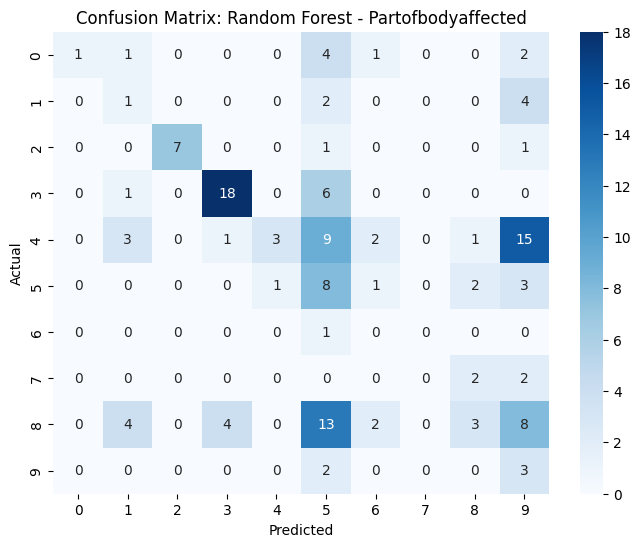

In [20]:
# ----------------------------
# Step 18: Confusion Matrix & Classification Report for Random Forest
# ----------------------------
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Function to plot confusion matrix
def plot_confusion(y_true, y_pred, target_name, model_name, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {model_name} - {target_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# ----------------------------
# Train the Random Forest model on SMOTE-balanced data
# ----------------------------
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)

# Predict on the untouched test set
y_pred_rf = rf.predict(X_test_num)

# ----------------------------
# Classification report and confusion matrix
# ----------------------------
target_name = 'Partofbodyaffected'

# Convert label encoder classes to strings
labels = le.classes_.astype(str)

print(f"\nClassification Report for {target_name} (Random Forest):")
print(classification_report(y_test_enc, y_pred_rf, target_names=labels, zero_division=0))

# ----------------------------
# Confusion Matrix
# ----------------------------
plot_confusion(y_test_enc, y_pred_rf, target_name, "Random Forest", labels)


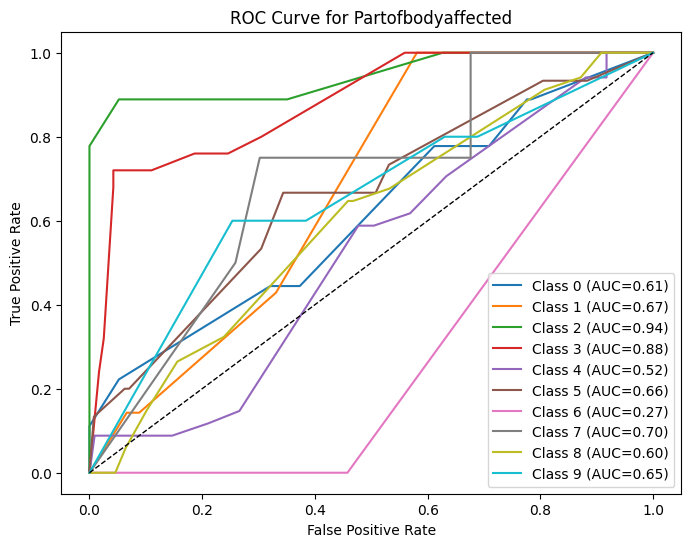

In [21]:
# ----------------------------
# ROC Curve for Random Forest
# ----------------------------
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_single_target(y_true, y_pred_proba, model_name="Model", target_name="Target"):
    plt.figure(figsize=(8,6))
    
    # Handle binary classification
    if y_pred_proba.ndim == 1 or y_pred_proba.shape[1] == 1 or len(np.unique(y_true)) == 2:
        # Binary case
        y_scores = (
            y_pred_proba[:, 1] if y_pred_proba.ndim > 1 and y_pred_proba.shape[1] > 1
            else y_pred_proba.ravel()
        )
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})', lw=2)
    else:
        # Multiclass case
        from sklearn.preprocessing import label_binarize
        classes = np.unique(y_true)
        y_true_bin = label_binarize(y_true, classes=classes)
        for i, class_label in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC={roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {target_name}')
    plt.legend(loc='lower right')
    plt.show()


# ----------------------------
# Compute predicted probabilities and plot
# ----------------------------
# Predict probabilities using the trained Random Forest
y_pred_proba = rf.predict_proba(X_test_num)

# Plot ROC curve
plot_roc_single_target(y_test_enc, y_pred_proba, model_name="Random Forest", target_name="Partofbodyaffected")


In [22]:
# ----------------------------
# Train Random Forest on SMOTE data and plot ROC
# ----------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Train the model
# ----------------------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

# ----------------------------
# Predict probabilities on test data
# ----------------------------
y_pred_proba = rf.predict_proba(X_test_scaled)

# ----------------------------
# Handle multi-class ROC curve
# ----------------------------
def plot_roc_single_target(y_test, y_pred_proba, model_name, target_name, model, label_encoder=None):
    """
    Plots multi-class ROC curve for one target.
    Handles alignment between encoded labels and model outputs.
    """
    # Get class labels from model
    classes = model.classes_
    y_test_bin = label_binarize(y_test, classes=classes)

    # Use readable class names if available
    if label_encoder is not None:
        class_labels = label_encoder.inverse_transform(classes)
    else:
        class_labels = [str(c) for c in classes]

    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(class_labels):
        # Skip if class missing from test set
        if y_test_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_label} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve for {target_name}")
    plt.legend(loc="lower right")
    plt.show()

# ----


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\Users\User\AppData\Local\Temp\ipykernel_33600\1667599525.py:64: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


🏆 Best Model: Decision Tree
F1 Score: 0.3084

              Model  Accuracy  Precision   Recall       F1
      Decision Tree  0.307692   0.556074 0.307692 0.308435
Logistic Regression  0.307692   0.556074 0.307692 0.308435
      Random Forest  0.307692   0.556074 0.307692 0.308435
                KNN  0.251748   0.210599 0.251748 0.220778


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


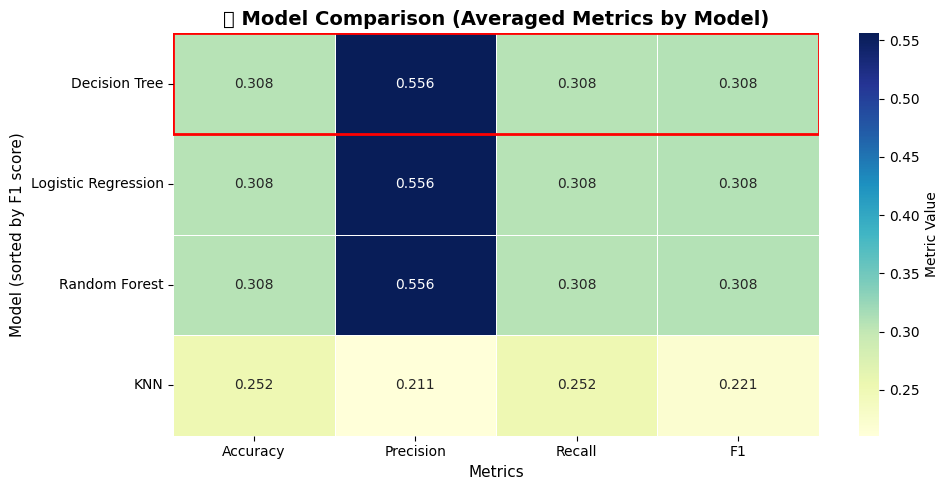

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Model comparison and visualization
# ----------------------------

# Ensure 'results_df' exists and contains the expected columns
expected_cols = {'Model', 'Accuracy', 'Precision', 'Recall', 'F1'}
missing_cols = expected_cols - set(results_df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing columns in results_df: {missing_cols}")

# Numeric metrics to aggregate
numeric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']

# Aggregate by model (mean if multiple runs)
comparison_table = (
    results_df
    .groupby('Model', as_index=False)[numeric_cols]
    .mean()
    .sort_values(by='F1', ascending=False)
    .reset_index(drop=True)
)

# Identify best model based on F1 score
best_model = comparison_table.iloc[0]['Model']
best_f1 = comparison_table.iloc[0]['F1']

print(" Best Model:", best_model)
print(f"F1 Score: {best_f1:.4f}\n")
print(comparison_table.to_string(index=False))

# ----------------------------
# Visualize model performance
# ----------------------------
plt.figure(figsize=(10, 5))
ax = sns.heatmap(
    comparison_table.set_index('Model'),
    annot=True,
    cmap='YlGnBu',
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'label': 'Metric Value'}
)

# Highlight the best model row
best_row_idx = comparison_table.index[comparison_table['Model'] == best_model][0]
ax.add_patch(
    plt.Rectangle(
        (0, best_row_idx),       # x, y position
        len(numeric_cols),        # width (number of metric columns)
        1,                        # height (one row)
        fill=False,
        edgecolor='red',
        lw=2
    )
)

plt.title("🔍 Model Comparison (Averaged Metrics by Model)", fontsize=14, weight='bold')
plt.ylabel("Model (sorted by F1 score)", fontsize=11)
plt.xlabel("Metrics", fontsize=11)
plt.tight_layout()
plt.show()


In [24]:
import joblib
import pandas as pd
import numpy as np
import os

# ----------------------------
# Identify and save best model
# ----------------------------
target_name = "Partofbodyaffected"

# Identify best model by F1 score
best_row = results_df.loc[results_df['F1'].idxmax()]
best_model_name = best_row['Model']
best_f1_score = best_row['F1']

# Retrieve corresponding model object and scaling flag
best_model_obj, use_scaling = models[best_model_name]

# Prepare correct training input (scaled or resampled)
X_train_input = X_train_scaled if use_scaling else X_train_res

# ----------------------------
# Ensure X_train_input is a DataFrame
# ----------------------------
if isinstance(X_train_input, np.ndarray):
    # Fall back to resampled DataFrame if available
    if 'X_train_res' in locals() and hasattr(X_train_res, 'columns'):
        feature_columns = X_train_res.columns
    else:
        # Otherwise, try fallback numeric column names
        feature_columns = [f'feature_{i}' for i in range(X_train_input.shape[1])]
    X_train_input = pd.DataFrame(X_train_input, columns=feature_columns)
else:
    feature_columns = X_train_input.columns

# ----------------------------
# Re-train best model
# ----------------------------
best_model_obj.fit(X_train_input, y_train_res)

# ----------------------------
# Save model artifacts
# ----------------------------
model_filename = f'best_model_{target_name}_{best_model_name.replace(" ", "_").lower()}.pkl'
columns_filename = f'training_columns_{target_name}.pkl'

# Create directory for models if it doesn’t exist
os.makedirs("models", exist_ok=True)

# Save artifacts
joblib.dump(best_model_obj, os.path.join("models", model_filename))
joblib.dump(list(feature_columns), os.path.join("models", columns_filename))

print(" Model training and saving complete!")
print(f" Best Model: {best_model_name}")
print(f"F1 Score: {best_f1_score:.4f}")
print(f"Model saved as: models/{model_filename}")
print(f"Training columns saved as: models/{columns_filename}")

if use_scaling:
    print(" Scaler already saved as: scaler.pkl")
else:
    print("ℹ Model trained without scaling.")









 Model training and saving complete!
 Best Model: Logistic Regression
F1 Score: 0.3084
Model saved as: models/best_model_Partofbodyaffected_logistic_regression.pkl
Training columns saved as: models/training_columns_Partofbodyaffected.pkl
 Scaler already saved as: scaler.pkl


In [ ]:

import joblib
import pandas as pd
import numpy as np
import os

# ----------------------------
# 1. Define target name
# ----------------------------
target_name = "Partofbodyaffected"

# ----------------------------
# 2. Load saved artifacts
# ----------------------------
# Automatically detect the best model file (instead of hardcoding KNN)
model_dir = "models"
model_files = [f for f in os.listdir(model_dir) if f.startswith(f"best_model_{target_name}")]
if not model_files:
    raise FileNotFoundError(f"No saved model found for {target_name} in '{model_dir}'.")

# Load the most recent/best model
model_path = os.path.join(model_dir, model_files[0])
best_model = joblib.load(model_path)

# Load label encoder and training columns
label_encoder_path = f"label_encoder_{target_name}.pkl"
training_columns_path = os.path.join(model_dir, f"training_columns_{target_name}.pkl")

label_encoder = joblib.load(label_encoder_path)
training_columns = joblib.load(training_columns_path)

# Try loading the scaler (optional)
try:
    scaler = joblib.load("scaler.pkl")
except FileNotFoundError:
    scaler = None

print(f" Loaded model: {model_path}")
print(f" Training columns: {len(training_columns)} features")
if scaler:
    print("Scaler loaded successfully.")
else:
    print("ℹ No scaler found — model likely trained without scaling.")

# ----------------------------
# 3. Align features before prediction
# ----------------------------
def align_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Align input DataFrame to match the model's training features.
    Adds missing columns as 0 and removes extras.
    """
    df = df.copy()

    # Add any missing columns
    for col in training_columns:
        if col not in df:
            df[col] = 0

    # Remove any unexpected columns
    df = df[training_columns]

    return df

# ----------------------------
# 4. Predict function
# ----------------------------
def predict_target(new_data: pd.DataFrame, use_scaling=False) -> pd.DataFrame:
    """
    Make predictions using the trained model.
    Automatically applies scaling if available.
    """
    # Align features
    X_new = align_features(new_data)

    # Apply scaling if needed
    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)

    # Predict numeric and label classes
    preds_num = best_model.predict(X_new)
    preds_label = label_encoder.inverse_transform(preds_num)

    # Return labeled DataFrame
    return pd.DataFrame({target_name: preds_label})

# ----------------------------
# 5. Example usage
# ----------------------------
sample_data = X_test_num.iloc[:5].copy()
predictions = predict_target(sample_data, use_scaling=True)  # Set to False if model not scaled
print("\n Sample Predictions:")
print(predictions)


 Loaded model: models\best_model_Partofbodyaffected_logistic_regression.pkl
 Training columns: 15 features
Scaler loaded successfully.

 Sample Predictions:
  Partofbodyaffected
0               Ribs
1              Death
2               Ribs
3               Ribs
4               Head


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [26]:
import pandas as pd

# Load Excel file
df = pd.read_excel("spss revised data.xlsx", engine='openpyxl')

# Save as CSV
df.to_csv("spss_revised_data.csv", index=False)

print("File converted successfully!")


File converted successfully!


In [ ]:
# The features that should be used for prediction
training_columns = joblib.load("models/training_columns_Partofbodyaffected.pkl")
print(training_columns)
print(f"\nTotal features expected: {len(training_columns)}")


['RootCauses_Crushed by Machine', 'RootCauses_Crushed by Object', 'RootCauses_Cut by Machine', 'RootCauses_Cut by Object', 'RootCauses_Electricution', 'RootCauses_Falling', 'RootCauses_Foreign object in eye', 'RootCauses_Hit by Machine', 'RootCauses_Hit by Metal', 'RootCauses_Hit by Object', 'RootCauses_Lifting heavy load', 'RootCauses_Pricked', 'RootCauses_Slipped and Fell', 'RootCauses_Strucked by Object', 'RootCauses_Tripped and Fell']

Total features expected: 15
